<center><h1><span style="color: green;">THỰC HÀNH BUỔI 10</span></h1></center>

# 1. PHẦN MÔ HÌNH K- TRUNG BÌNH (K-MEANS MODEL)

## Ví dụ 1.

### 1.1 Python

In [ ]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)

# Kỳ vọng và hiệp phương sai của 3 cụm dữ liệu
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]

# Số điểm mỗi cụm dữ liệu
N = 500

# Tạo các cụm dữ liệu qua phân bố chuẩn (Gaussian)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
# Tổng hợp dữ liệu từ các cụm
X = np.concatenate((X0, X1, X2), axis = 0)

# Số cụm = 3
K = 3

# Gán nhãn ban đầu cho các cụm, sau đó ta test model và so sánh
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

 Hiển thị dữ liệu X lên mặt phẳng, ở đây sử dụng thông tin nhãn đã được gán ở phần trước trong tham đối label

In [ ]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]

    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)
    plt.axis('equal')
    plt.plot()
    plt.show()


Khởi tạo một bộ tâm cụm trên dữ liệu X với giả thiết có k cụm

In [ ]:
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

Phương thức để gán cụm cho một điểm dữ liệu bằng cách tính khoảng cách từ điểm đó đến các tâm cụm, khoảng cách đến đâu ngắn nhất thì ta coi điểm hiện tại sẽ thuộc về cụm đó.

In [ ]:
def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

Phương thức để cập nhật lại tâm cụm sau mỗi bước lặp: Tâm cụm mới sẽ là trung bình cộng (theo tọa độ) của tất cả các điểm có trong cụm

In [ ]:
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

Hàm để kiểm tra xem thuật toán có thực sự chạy (có hội tụ hay không) thông qua việc tâm cụm sau mỗi bước lặp có thay đổi hay không? Nếu tâm cụm không đổi nghĩa là thuật toán đã dừng (hội tụ) – tức là cần trả về TRUE. Kiểm tra cho tất cả các tâm cụm

In [ ]:
def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) ==
    set([tuple(a) for a in new_centers]))

Vòng lặp để thực hiện tất cả các bước trong thuật toán k-means cho đến khi thuật toán dừng

In [ ]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
          break
        centers.append(new_centers)
    it += 1
    return (centers, labels, it)

Gọi và thực hiện phương pháp

Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


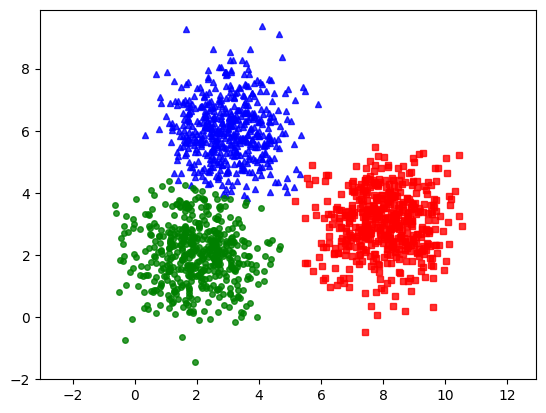

In [ ]:
(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])

kmeans_display(X, labels[-1])

### 2. Thực hiện bằng thư viện sklearn.

Centers found by scikit-learn:
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


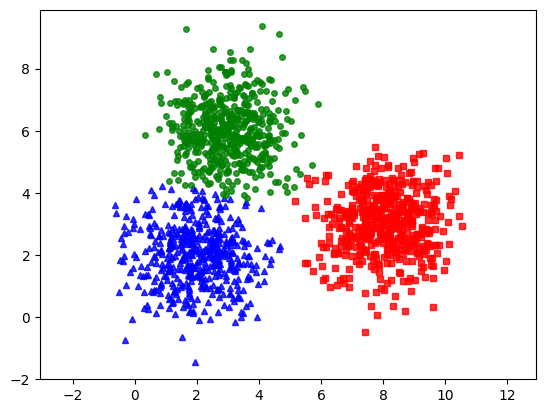

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

## Ví dụ 2: Thực hiện phân cụm cho bộ dữ liệu chữ số viết tay

In [ ]:
!pip install python-mnist
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

Xây dựng phương thức để hiện thị dữ liệu:

In [ ]:
def display_network(A, m = -1, n = -1):
    opt_normalize = True
    opt_graycolor = True

    # Rescale
    A = A - np.average(A)

    # Compute rows & cols
    (row, col) = A.shape
    sz = int(np.ceil(np.sqrt(row)))
    buf = 1
    if m < 0 or n < 0:
        n = np.ceil(np.sqrt(col))
        m = np.ceil(col / n)

    image = np.ones(shape=(buf + m * (sz + buf), buf + n * (sz + buf)))

    if not opt_graycolor:
        image *= 0.1

    k = 0
    for i in range(int(m)):
        for j in range(int(n)):
            if k >= col:
                continue

            clim = np.max(np.abs(A[:, k]))

            if opt_normalize:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +buf):buf + j * (sz + buf) + sz] = \
                A[:, k].reshape(sz, sz) / clim
            else:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +buf):buf + j * (sz + buf) + sz] = \
                A[:, k].reshape(sz, sz) / np.max(np.abs(A))
            k += 1
    return image


def display_color_network(A):
    """
    # display receptive field(s) or basis vector(s) for image patches
    #
    # A the basis, with patches as column vectors
    # In case the midpoint is not set at 0, we shift it dynamically
    :param A:
    :param file:
    :return:
    """
    if np.min(A) >= 0:
        A = A - np.mean(A)

    cols = np.round(np.sqrt(A.shape[1]))

    channel_size = A.shape[0] / 3
    dim = np.sqrt(channel_size)
    dimp = dim + 1
    rows = np.ceil(A.shape[1] / cols)

    B = A[0:channel_size, :]
    C = A[channel_size:2 * channel_size, :]
    D = A[2 * channel_size:3 * channel_size, :]

    B = B / np.max(np.abs(B))
    C = C / np.max(np.abs(C))
    D = D / np.max(np.abs(D))

    # Initialization of the image
    image = np.ones(shape=(dim * rows + rows - 1, dim * cols + cols - 1, 3))
    for i in range(int(rows)):
        for j in range(int(cols)):
            # This sets the patch
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 0] = B[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 1] = C[:, i * cols + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 2] = D[:, i * cols + j].reshape(dim, dim)

    image = (image + 1) / 2

    return image

In [ ]:

print(os.listdir('/content/drive/MyDrive/Classroom/MachineLearning/Lab10'))

['Sales_Transactions_Dataset_Weekly.csv', 'input.txt', 'DBScan_Method .ipynb', 'input.csv']


In [ ]:
drive.flush_and_unmount()  # Ngắt kết nối Drive
drive.mount('/content/drive')  # Gắn lại
print(os.listdir(data_path))

Mounted at /content/drive
['Sales_Transactions_Dataset_Weekly.csv', 'input.txt', 'DBScan_Method .ipynb', 'input.csv']


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA

def get_mnist_data(num_images, shuffle=True, image_size=28):
    """
    Load MNIST data directly from TensorFlow and return num_images samples.

    Parameters:
    - num_images: Number of images to return
    - shuffle: Whether to randomly select images
    - image_size: Size of each image (default 28 for MNIST)

    Returns:
    - images: Array of shape (num_images, image_size * image_size)
    - labels: Array of shape (num_images,)
    """
    # Load MNIST dataset
    (train_images, train_labels), (_, _) = mnist.load_data()

    # Total number of training images
    real_num = train_images.shape[0]  # 60000 for MNIST train

    if shuffle:
        # Randomly select num_images indices
        indices = np.random.permutation(real_num)[:num_images]
    else:
        # Select first num_images
        indices = np.arange(num_images)

    # Extract images and labels
    images = train_images[indices].astype(np.float32)
    labels = train_labels[indices].astype(np.int64)

    # Reshape images to vectors (num_images, 28*28)
    images = images.reshape(num_images, image_size * image_size)

    return images, labels

# 1) Đọc 1000 ảnh bất kỳ từ tập train, mỗi ảnh kích thước 28x28=784.
num_images = 1000
images_1000, labels_1000 = get_mnist_data(num_images=num_images,
                                         shuffle=True,
                                         image_size=28)

print('Kích thước tập ảnh ban đầu:', images_1000.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kích thước tập ảnh ban đầu: (1000, 784)


In [ ]:
# 2) Normalize data to [0, 1]
X = images_1000 / 255.0

# 3) Perform KMeans clustering with K=10
K = 10
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X)

# Predict cluster labels
pred_clusters = kmeans.labels_

Type of cluster centers: <class 'numpy.ndarray'>
Shape of cluster centers (transposed): (784, 10)


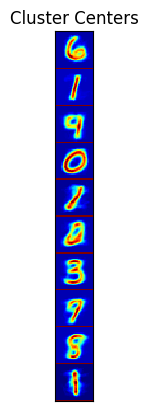

In [ ]:
# 4) Visualize cluster centers
import imageio # Import the imageio module

print('Type of cluster centers:', type(kmeans.cluster_centers_))
print('Shape of cluster centers (transposed):', kmeans.cluster_centers_.T.shape)

# Display cluster centers as a grid (10 columns, 1 row)
A = display_network(kmeans.cluster_centers_.T, K, 1)
f1 = plt.imshow(A, interpolation='nearest', cmap="jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.title('Cluster Centers')
plt.show()

# Save the cluster centers visualization
cmap = plt.cm.jet
norm = plt.Normalize(vmin=A.min(), vmax=A.max())
image = cmap(norm(A))
imageio.imwrite('cluster_centers.png', (image * 255).astype(np.uint8))

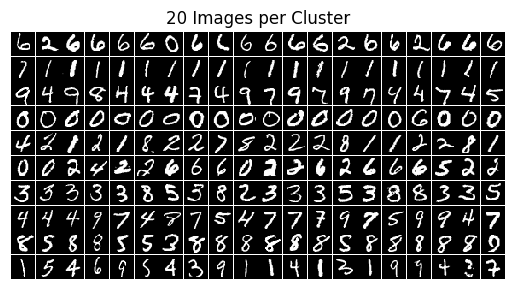

In [ ]:
# 5) Display N0 images closest to each cluster center
N0 = 20
X1 = np.zeros((N0 * K, 784))
X2 = np.zeros((N0 * K, 784))

# Iterate through each cluster
for k in range(K):
    # Get images in cluster k
    Xk = X[pred_clusters == k, :]

    if Xk.shape[0] == 0:
        print(f"Warning: Cluster {k} is empty, skipping...")
        continue

    # Find images closest to the cluster center
    center_k = kmeans.cluster_centers_[k].reshape(1, -1)
    neigh = NearestNeighbors(n_neighbors=min(N0, Xk.shape[0]))
    neigh.fit(Xk)
    dist, nearest_id = neigh.kneighbors(center_k, n_neighbors=min(N0, Xk.shape[0]))

    # Store nearest images in X1 and first N0 images in X2
    X1[N0 * k: N0 * k + len(nearest_id.flatten()), :] = Xk[nearest_id.flatten(), :]
    X2[N0 * k: N0 * k + min(N0, Xk.shape[0]), :] = Xk[:min(N0, Xk.shape[0]), :]

# Display representative images (10 columns, N0 rows)
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation='nearest', cmap='gray')
plt.title(f'{N0} Images per Cluster')
plt.show()

# Save the representative images visualization
image = plt.cm.gray(norm(A))
imageio.imwrite('cluster_images.png', (image * 255).astype(np.uint8))

## Bài 1.2. Áp dụng mô hình trên cho bài tập phân loại ảnh chó-mèo (xem lại phần CNN), thử thực hiện phân cụm thành 02 cụm và kiểm tra kết quả.

Mounted at /content/drive
Contents of base directory: ['vectorize.py', 'validation', 'train']
Contents of train directory: ['dogs', 'cats']
Total training cat images: 1000
Total training dog images: 1000
Kích thước tập ảnh ban đầu: (1000, 12288)
Type of cluster centers: <class 'numpy.ndarray'>
Shape of cluster centers (transposed): (12288, 2)


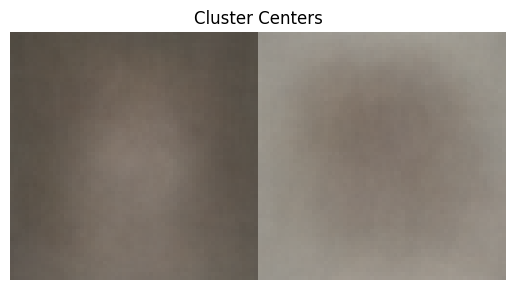

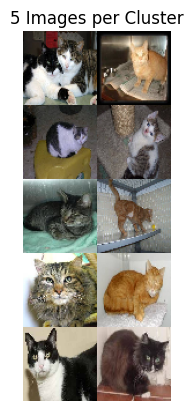

Adjusted Rand Index: 2.3166329322693964e-05
Cluster composition (Cats, Dogs):
Cluster 0: 255 cats, 239 dogs
Cluster 1: 245 cats, 261 dogs
Clustering accuracy (after mapping): 0.516
Confusion Matrix:
[[255 245]
 [239 261]]


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import imageio
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Paths
drive_path = '/content/drive/MyDrive/Classroom/MachineLearning'
local_zip = os.path.join(drive_path, 'cats_and_dogs_filtered.zip')
base_dir = os.path.join(drive_path, 'cats_and_dogs_filtered')

# Extract ZIP file if not already extracted
if not os.path.exists(base_dir):
    zip_ref = zipfile.ZipFile(local_zip, 'r')
    zip_ref.extractall(drive_path)
    zip_ref.close()

# Define directories
train_dir = os.path.join(base_dir, 'train')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Verify directory contents
print("Contents of base directory:", os.listdir(base_dir))
print("Contents of train directory:", os.listdir(train_dir))
print('Total training cat images:', len(os.listdir(train_cats_dir)))
print('Total training dog images:', len(os.listdir(train_dogs_dir)))

# Function to load and preprocess images
def load_cats_dogs_data(num_images, image_size=64):
    """
    Load and preprocess cat and dog images.

    Parameters:
    - num_images: Total number of images to load (split evenly between cats and dogs)
    - image_size: Size to resize images (image_size x image_size)

    Returns:
    - images: Array of shape (num_images, image_size * image_size * 3)
    - labels: Array of shape (num_images,) (0 for cats, 1 for dogs)
    """
    train_cat_fnames = os.listdir(train_cats_dir)
    train_dog_fnames = os.listdir(train_dogs_dir)

    # Load equal number of cat and dog images
    num_per_class = num_images // 2
    cat_fnames = np.random.choice(train_cat_fnames, num_per_class, replace=False)
    dog_fnames = np.random.choice(train_dog_fnames, num_per_class, replace=False)

    images = []
    labels = []

    # Load cat images
    for fname in cat_fnames:
        img_path = os.path.join(train_cats_dir, fname)
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img).astype(np.float32) / 255.0  # Normalize to [0, 1]
        images.append(img_array.flatten())
        labels.append(0)  # 0 for cats

    # Load dog images
    for fname in dog_fnames:
        img_path = os.path.join(train_dogs_dir, fname)
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img).astype(np.float32) / 255.0
        images.append(img_array.flatten())
        labels.append(1)  # 1 for dogs

    return np.array(images), np.array(labels)

# Function to display image grid
def display_network(images, n_cols, n_rows, image_size=64, channels=3):
    """
    Display a grid of images.

    Parameters:
    - images: Array of shape (image_size * image_size * channels, n_cols * n_rows)
    - n_cols: Number of columns in the grid
    - n_rows: Number of rows in the grid
    - image_size: Size of each image
    - channels: Number of color channels (3 for RGB)

    Returns:
    - A: Array of shape (n_rows * image_size, n_cols * image_size, channels)
    """
    images = images.T.reshape(-1, image_size, image_size, channels)
    A = np.zeros((n_rows * image_size, n_cols * image_size, channels))
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            if idx < images.shape[0]:
                A[i * image_size:(i + 1) * image_size, j * image_size:(j + 1) * image_size, :] = images[idx]
    return A

# 1) Load 1000 images (500 cats, 500 dogs)
num_images = 1000
image_size = 64
X, y = load_cats_dogs_data(num_images=num_images, image_size=image_size)
print('Kích thước tập ảnh ban đầu:', X.shape)

# 2) Perform KMeans clustering with K=2
K = 2
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X)
pred_clusters = kmeans.labels_

# 3) Visualize cluster centers
print('Type of cluster centers:', type(kmeans.cluster_centers_))
print('Shape of cluster centers (transposed):', kmeans.cluster_centers_.T.shape)
A = display_network(kmeans.cluster_centers_.T, K, 1, image_size=image_size, channels=3)
plt.imshow(A)
plt.axis('off')
plt.title('Cluster Centers')
plt.show()
imageio.imwrite('cats_dogs_cluster_centers.png', (A * 255).astype(np.uint8))

# 4) Display N0 images closest to each cluster center
N0 = 5
X1 = np.zeros((N0 * K, image_size * image_size * 3))
X2 = np.zeros((N0 * K, image_size * image_size * 3))

for k in range(K):
    Xk = X[pred_clusters == k, :]
    if Xk.shape[0] == 0:
        print(f"Warning: Cluster {k} is empty, skipping...")
        continue
    center_k = kmeans.cluster_centers_[k].reshape(1, -1)
    neigh = NearestNeighbors(n_neighbors=min(N0, Xk.shape[0]))
    neigh.fit(Xk)
    dist, nearest_id = neigh.kneighbors(center_k, n_neighbors=min(N0, Xk.shape[0]))
    X1[N0 * k: N0 * k + len(nearest_id.flatten()), :] = Xk[nearest_id.flatten(), :]
    X2[N0 * k: N0 * k + min(N0, Xk.shape[0]), :] = Xk[:min(N0, Xk.shape[0]), :]

# Display representative images
A = display_network(X2.T, K, N0, image_size=image_size, channels=3)
plt.imshow(A)
plt.axis('off')
plt.title(f'{N0} Images per Cluster')
plt.show()
imageio.imwrite('cats_dogs_cluster_images.png', (A * 255).astype(np.uint8))

# 5) Evaluate clustering performance
from sklearn.metrics import adjusted_rand_score, confusion_matrix
ari = adjusted_rand_score(y, pred_clusters)
print(f'Adjusted Rand Index: {ari}')

# Map clusters to labels (assuming cluster with more cats is labeled as 0)
cluster_counts = np.zeros((K, 2))  # [cluster][true_label]
for k in range(K):
    cluster_labels = y[pred_clusters == k]
    cluster_counts[k, 0] = np.sum(cluster_labels == 0)  # Cats
    cluster_counts[k, 1] = np.sum(cluster_labels == 1)  # Dogs

print('Cluster composition (Cats, Dogs):')
for k in range(K):
    print(f'Cluster {k}: {int(cluster_counts[k, 0])} cats, {int(cluster_counts[k, 1])} dogs')

# Assign cluster to class based on majority
cluster_to_class = np.argmax(cluster_counts, axis=1)
mapped_labels = np.array([cluster_to_class[c] for c in pred_clusters])
accuracy = np.mean(mapped_labels == y)
print(f'Clustering accuracy (after mapping): {accuracy}')

# Confusion matrix
cm = confusion_matrix(y, mapped_labels)
print('Confusion Matrix:')
print(cm)

# 2. PHẦN MÔ HÌNH DBSCAN

## Ví dụ 2.1

Ta xây dựng Class DBScan, trong đó khi khởi tạo sẽ có đầu vào là epsilon và minppts và dữ liệu đầu vào cần phân cụm là input

In [ ]:
class DBSCAN(object):

    def __init__(self,x,epsilon,minpts):
        # The number of input dataset
        self.n = len(x)
        # Euclidean distance
        p, q = np.meshgrid(np.arange(self.n), np.arange(self.n))
        self.dist = np.sqrt(np.sum(((x[p] - x[q])**2),2))
        # label as visited points and noise
        self.visited = np.full((self.n), False)
        self.noise = np.full((self.n),False)
        # DBSCAN Parameters
        self.epsilon = epsilon
        self.minpts = minpts
        # Cluseter
        self.idx = np.full((self.n),0)
        self.C = 0
        self.input = x

    def run(self):
        # Clustering
        for i in range(len(self.input)):
            if self.visited[i] == False:
                self.visited[i] = True
                self.neighbors = self.regionQuery(i)
                if len(self.neighbors) >= self.minpts:
                    self.C += 1
                    self.expandCluster(i)
                else : self.noise[i] = True
        return self.idx,self.noise

    def regionQuery(self, i):
        g = self.dist[i,:] < self.epsilon
        Neighbors = np.where(g)[0].tolist()
        return Neighbors

    def expandCluster(self, i):
        self.idx[i] = self.C
        k = 0

        while True:
            if len(self.neighbors) <= k:return
            j = self.neighbors[k]
            if self.visited[j] != True:
                self.visited[j] = True

                self.neighbors2 = self.regionQuery(j)
                v = [self.neighbors2[i] for i in np.where(self.idx[self.neighbors2]==0)[0]]

                if len(self.neighbors2) >=  self.minpts:
                    self.neighbors = self.neighbors+v

            if self.idx[j] == 0 : self.idx[j] = self.C
            k += 1

    def sort(self):

        cnum = np.max(self.idx)
        self.cluster = []
        self.noise = []
        for i in range(cnum):

            k = np.where(self.idx == (i+1))[0].tolist()
            self.cluster.append([self.input[k,:]])

        self.noise = self.input[np.where(self.idx == 0)[0].tolist(),:]
        return self.cluster, self.noise

    def plot(self):

        self.sort()
        fig,ax = plt.subplots()

        for idx,group in enumerate(self.cluster):

            ax.plot(group[0][:,0],
                    group[0][:,1],
                    marker='o',
                    linestyle='',
                    label='Cluster {}'.format(idx))

            if self.noise != None:
                ax.plot(self.noise[:,0],
                    self.noise[:,1],
                    marker='x',
                    linestyle='',
                    label='noise')

        ax.legend(fontsize=10, loc='upper left')
        plt.title('Scatter Plot of Clustering result', fontsize=15)
        plt.xlabel('X', fontsize=14)
        plt.ylabel('Y', fontsize=14)
        plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


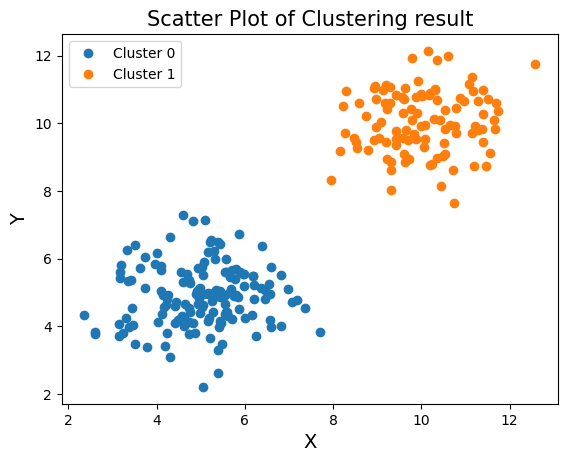

In [ ]:
from scipy import io
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/drive/MyDrive/Classroom/MachineLearning/Lab10/input.csv')
x = np.zeros([len(df), 2], float )
x[:, 0] = np.array(df['x1'], float)
x[:, 1] = np.array(df['x2'], float)
#%% Run DEMO
# INIT DBSCAN
dbscan = DBSCAN(x,1.5,4)
# CLUSTERING
idx,noise = dbscan.run()
# SORTING
g_cluster,n_cluster = dbscan.sort()
# Visualization
dbscan.plot()

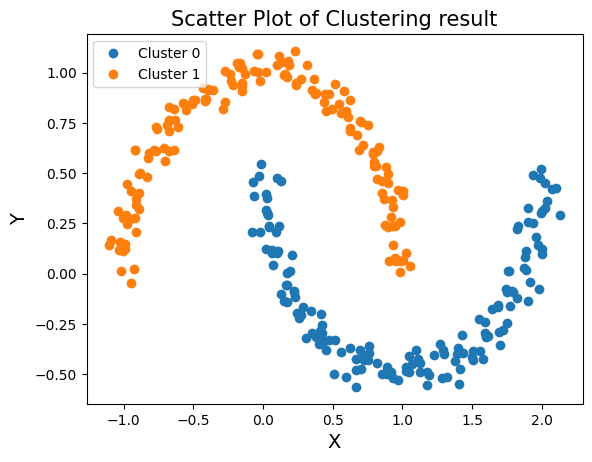

In [ ]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# INIT DBSCAN
dbscan = DBSCAN(X, 0.3, 5)
# CLUSTERING
idx,noise = dbscan.run()
# SORTING
g_cluster,n_cluster = dbscan.sort()
# Visualization
dbscan.plot()

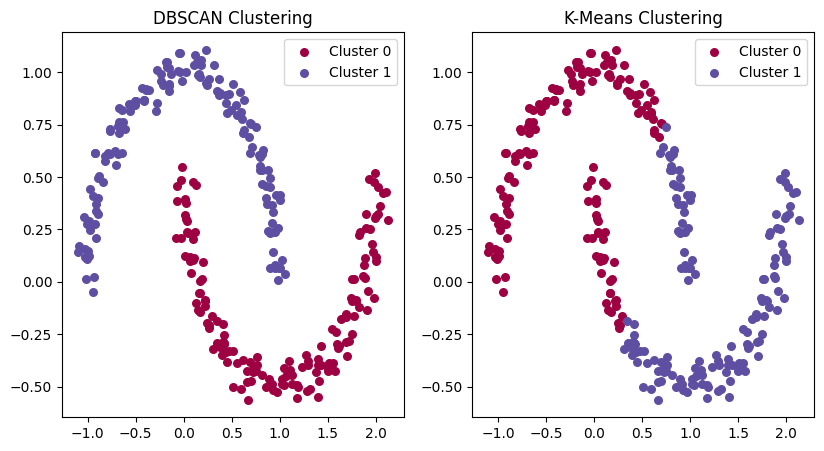

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons

# Generate synthetic data (you can replace this with your own data)
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)


# Plot the results for DBSCAN
plt.figure(figsize=(15, 5))

plt.subplot(131)
unique_labels_dbscan = np.unique(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_dbscan)))

for label, color in zip(unique_labels_dbscan, colors):
    if label == -1:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color='gray', s=10, label='Noise')
    else:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('DBSCAN Clustering')
plt.legend()

# Plot the results for K-Means
plt.subplot(132)
unique_labels_kmeans = np.unique(kmeans_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_kmeans)))

for label, color in zip(unique_labels_kmeans, colors):
    plt.scatter(X[kmeans_labels == label][:, 0], X[kmeans_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('K-Means Clustering')
plt.legend()

plt.show()

### Bài tập 2.1. Thực hiện phân cụm bằng phương pháp K-means với dữ liệu tạo ra trong Ví dụ 2.1

In [ ]:
class KMeansClustering(object):
    def __init__(self, x, n_clusters, random_state=42):
        # Input dataset and parameters
        self.n = len(x)
        self.input = x
        self.n_clusters = n_clusters
        self.random_state = random_state
        # Cluster labels
        self.idx = np.zeros(self.n, dtype=int)
        # Centroids
        self.centroids = None

    def run(self):
        # Initialize centroids randomly
        np.random.seed(self.random_state)
        indices = np.random.choice(self.n, self.n_clusters, replace=False)
        self.centroids = self.input[indices].copy()

        while True:
            # Assign points to nearest centroid
            old_idx = self.idx.copy()
            for i in range(self.n):
                distances = np.sqrt(np.sum((self.input[i] - self.centroids) ** 2, axis=1))
                self.idx[i] = np.argmin(distances)

            # Update centroids
            for k in range(self.n_clusters):
                if np.sum(self.idx == k) > 0:  # Avoid empty clusters
                    self.centroids[k] = np.mean(self.input[self.idx == k], axis=0)

            # Check for convergence
            if np.all(old_idx == self.idx):
                break

        return self.idx

    def sort(self):
        # Organize points by cluster
        self.clusters = []
        for k in range(self.n_clusters):
            cluster_points = self.input[self.idx == k]
            self.clusters.append(cluster_points)
        return self.clusters

    def plot(self):
        self.sort()
        fig, ax = plt.subplots()

        # Plot each cluster
        for idx, group in enumerate(self.clusters):
            if len(group) > 0:  # Only plot non-empty clusters
                ax.plot(group[:, 0], group[:, 1], marker='o', linestyle='',
                        label=f'Cluster {idx}')

        # Plot centroids
        ax.plot(self.centroids[:, 0], self.centroids[:, 1], marker='x', linestyle='',
                color='black', label='Centroids', markersize=10)

        ax.legend(fontsize=10, loc='upper left')
        plt.title('Scatter Plot of K-Means Clustering Result', fontsize=15)
        plt.xlabel('X', fontsize=14)
        plt.ylabel('Y', fontsize=14)
        plt.show()

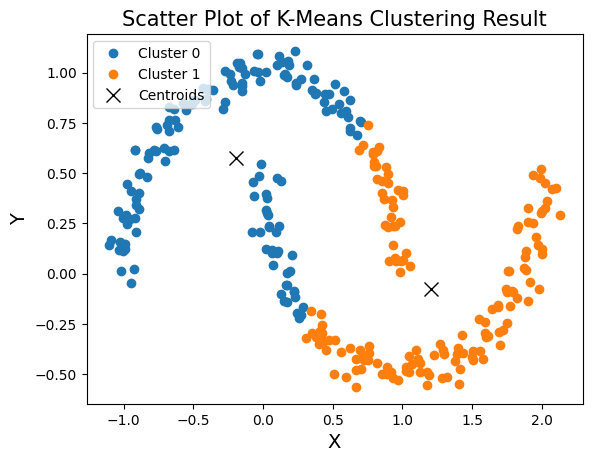

In [ ]:
# Generate synthetic data (same as in the provided code)
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Initialize and run K-Means
kmeans = KMeansClustering(X, n_clusters=2, random_state=42)
idx = kmeans.run()
clusters = kmeans.sort()
kmeans.plot()

### Bài tập 2.2

In [3]:
# Ngắt kết nối Google Drive
from google.colab import drive
drive.flush_and_unmount()

# Kết nối lại Google Drive
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Đọc dữ liệu từ file CSV
df = pd.read_csv('/content/drive/MyDrive/Classroom/MachineLearning/Lab10/Sales_Transactions_Dataset_Weekly.csv')
df.head()

,Product_Code,W0,W1,W2,W3,W4,W5,W6,W7,W8,...,Normalized 42,Normalized 43,Normalized 44,Normalized 45,Normalized 46,Normalized 47,Normalized 48,Normalized 49,Normalized 50,Normalized 51
0,P1,11,12,10,8,13,12,14,21,6,...,0.06,0.22,0.28,0.39,0.50,0.00,0.22,0.17,0.11,0.39
1,P2,7,6,3,2,7,1,6,3,3,...,0.20,0.40,0.50,0.10,0.10,0.40,0.50,0.10,0.60,0.00
2,P3,7,11,8,9,10,8,7,13,12,...,0.27,1.00,0.18,0.18,0.36,0.45,1.00,0.45,0.45,0.36
3,P4,12,8,13,5,9,6,9,13,13,...,0.41,0.47,0.06,0.12,0.24,0.35,0.71,0.35,0.29,0.35
4,P5,8,5,13,11,6,7,9,14,9,...,0.27,0.53,0.27,0.60,0.20,0.20,0.13,0.53,0.33,0.40


In [6]:
# Chọn cột chứa dữ liệu chuẩn hóa (Normalized Week 0 đến Week 51)
norm_cols = [col for col in df.columns if col.startswith('Normalized')]
X = df[norm_cols].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Hàm tìm số cụm tối ưu dựa trên silhouette score
def find_optimal_clusters(X, eps=2.0, min_samples=3, max_clusters=15):
    best_n_clusters = 5
    best_score = -1
    best_labels = None

    for n in range(5, max_clusters + 1):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # Đếm số cụm (loại bỏ nhiễu -1)
        unique_labels = set(labels) - {-1}
        n_clusters = len(unique_labels)

        # Chỉ tính silhouette score nếu số cụm trong khoảng 5-15
        if 5 <= n_clusters <= max_clusters and len(unique_labels) > 1:
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_n_clusters = n_clusters
                best_labels = labels

    return best_n_clusters, best_labels

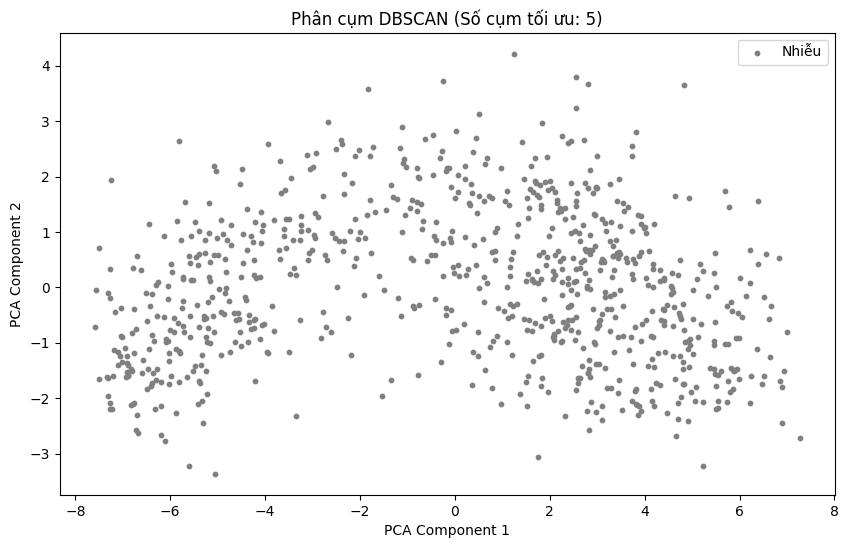

In [11]:
# Tìm số cụm tối ưu với eps và min_samples điều chỉnh
optimal_clusters, optimal_labels = find_optimal_clusters(X_scaled, eps=2.0, min_samples=3)

# Áp dụng DBSCAN với tham số đã điều chỉnh
dbscan = DBSCAN(eps=2.0, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Gán nhãn cụm cho dữ liệu
df['Cluster'] = labels

# Lưu kết quả vào file CSV
df[['Product_Code', 'Cluster'] + norm_cols].to_csv('sales_clustering_results.csv', index=False)

# Vẽ biểu đồ phân cụm (giảm chiều dữ liệu xuống 2D để trực quan hóa)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        plt.scatter(X_pca[labels == label][:, 0], X_pca[labels == label][:, 1],
                   color='gray', s=10, label='Nhiễu')
    else:
        plt.scatter(X_pca[labels == label][:, 0], X_pca[labels == label][:, 1],
                   color=color, s=30, label=f'Cụm {label}')

plt.title(f'Phân cụm DBSCAN (Số cụm tối ưu: {optimal_clusters})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.savefig('sales_clustering_plot.png')

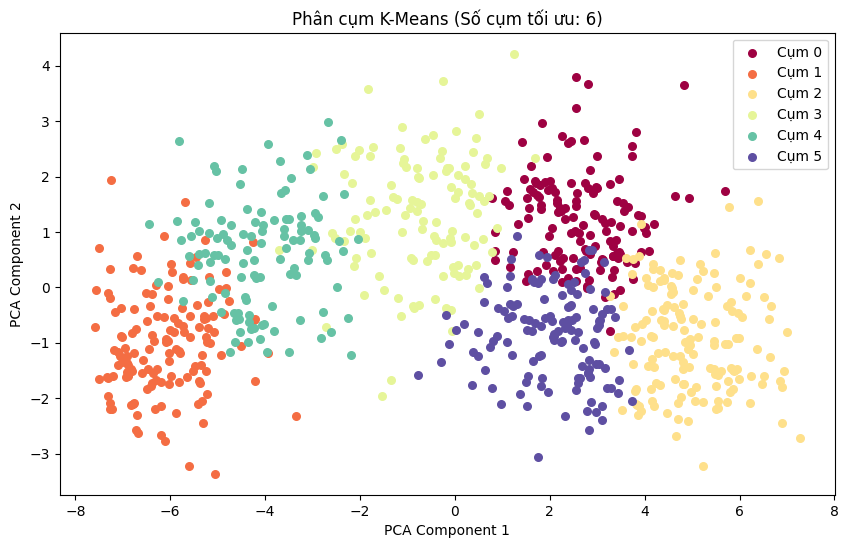

In [12]:
# Thay thế phần tìm cụm và phân cụm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hàm tìm số cụm tối ưu bằng phương pháp elbow
def find_optimal_clusters_kmeans(X, max_clusters=15):
    inertias = []
    for n in range(5, max_clusters + 1):
        kmeans = KMeans(n_clusters=n, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    # Chọn số cụm tối ưu (elbow point)
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    optimal_n = 5 + np.argmax(diffs2) + 1
    return optimal_n

# Tìm số cụm tối ưu
optimal_clusters = find_optimal_clusters_kmeans(X_scaled)

# Áp dụng K-Means
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Gán nhãn cụm cho dữ liệu
df['Cluster'] = labels

# Lưu kết quả vào file CSV
df[['Product_Code', 'Cluster'] + norm_cols].to_csv('sales_clustering_results.csv', index=False)

# Vẽ biểu đồ phân cụm
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    plt.scatter(X_pca[labels == label][:, 0], X_pca[labels == label][:, 1],
                color=color, s=30, label=f'Cụm {label}')

plt.title(f'Phân cụm K-Means (Số cụm tối ưu: {optimal_clusters})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.savefig('sales_clustering_plot.png')

**Nhận xét K-Means:**
- K-Means phân dữ liệu thành 6 cụm, mỗi cụm được biểu diễn bằng màu khác nhau.
- Các cụm phân bố khá đều, nhưng có sự chồng lấn đáng kể giữa các cụm (đặc biệt ở vùng trung tâm), cho thấy dữ liệu không có ranh giới cụm rõ ràng.
- K-Means chia cụm dựa trên khoảng cách Euclidean, nên phù hợp hơn với dữ liệu phân tán đều, nhưng không xử lý tốt nếu dữ liệu có hình dạng phức tạp.

**Nhận xét DBSCAN:**
- DBSCAN không tạo được cụm, toàn bộ điểm bị đánh dấu là nhiễu (hình trước đó).
- Nguyên nhân: Dữ liệu giao dịch không có mật độ đủ cao hoặc cấu trúc cụm rõ ràng để DBSCAN nhận diện, ngay cả khi điều chỉnh `eps` và `min_samples`.
- DBSCAN phù hợp với dữ liệu có mật độ khác biệt rõ ràng (như make_moons trong ví dụ 1), nhưng không hiệu quả với dữ liệu giao dịch này.

**So sánh:**
- K-Means hoạt động tốt hơn DBSCAN trong trường hợp này, vì nó vẫn phân được cụm dù dữ liệu phân tán và không có mật độ rõ ràng.
- Tuy nhiên, kết quả K-Means vẫn chưa tối ưu do chồng lấn cụm.